# Module 1 Notebook A: Linear Regression From Scratch

This notebook implements core Module 1 concepts without ML libraries:
- linear regression model
- MSE and MAE
- gradient descent
- learning-rate behavior
- outlier sensitivity

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 4)

## 1) Create Synthetic Data

True relationship: `y = 3x + 2 + noise`

X shape: (120,), y shape: (120,)


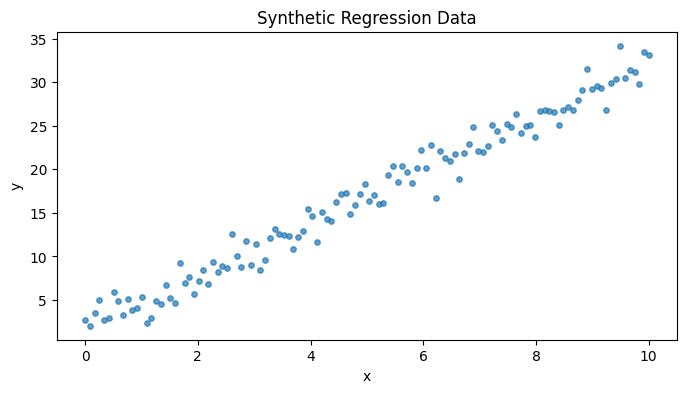

In [2]:
X = np.linspace(0, 10, 120)
noise = np.random.normal(0, 1.5, size=X.shape)
y = 3 * X + 2 + noise

print(f"X shape: {X.shape}, y shape: {y.shape}")

plt.scatter(X, y, s=15, alpha=0.7)
plt.title("Synthetic Regression Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 2) Define Losses and Gradients

In [3]:
def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))


def gradients(x, y_true, y_pred):
    n = len(x)
    error = y_pred - y_true
    dw = (2 / n) * np.sum(error * x)
    db = (2 / n) * np.sum(error)
    return dw, db

## 3) Train With Gradient Descent

In [4]:
def train_linear_regression_gd(x, y_true, lr=0.01, epochs=2000):
    w, b = 0.0, 0.0
    history = []

    for _ in range(epochs):
        y_pred = w * x + b
        loss = mse(y_true, y_pred)
        dw, db = gradients(x, y_true, y_pred)

        w -= lr * dw
        b -= lr * db
        history.append(loss)

    return w, b, np.array(history)

w, b, history = train_linear_regression_gd(X, y, lr=0.01, epochs=3000)
print(f"Learned parameters -> w: {w:.4f}, b: {b:.4f}")
print(f"Final MSE: {history[-1]:.4f}")

Learned parameters -> w: 3.0368, b: 1.6971
Final MSE: 1.8989


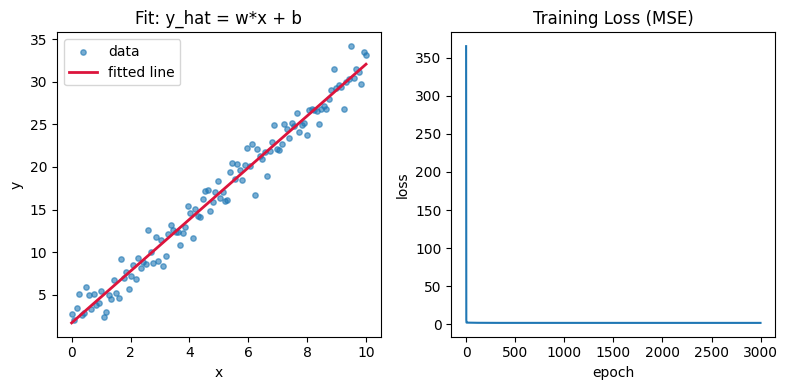

In [5]:
y_hat = w * X + b

plt.subplot(1, 2, 1)
plt.scatter(X, y, s=15, alpha=0.6, label='data')
plt.plot(X, y_hat, color='crimson', linewidth=2, label='fitted line')
plt.title('Fit: y_hat = w*x + b')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history)
plt.title('Training Loss (MSE)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.tight_layout()
plt.show()

## 4) Learning Rate Comparison

/Users/niketgirdhar/.pyenv/versions/3.12.3/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/15/ntlyk3ln0p9by83mk1kl86dc0000gn/T/ipykernel_42512/715534907.py:2: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y_true) ** 2)
/Users/niketgirdhar/.pyenv/versions/3.12.3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/15/ntlyk3ln0p9by83mk1kl86dc0000gn/T/ipykernel_42512/794505532.py:6: RuntimeWarning: invalid value encountered in multiply
  y_pred = w * x + b


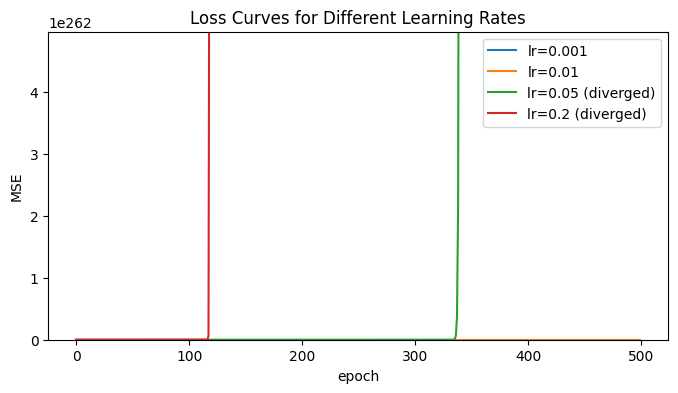

In [6]:
rates = [0.001, 0.01, 0.05, 0.2]
results = {}

for lr in rates:
    _, _, h = train_linear_regression_gd(X, y, lr=lr, epochs=500)
    results[lr] = np.asarray(h, dtype=float)

for lr, h in results.items():
    finite = np.isfinite(h)
    if finite.any():
        last_finite_idx = np.where(finite)[0][-1]
        label = f"lr={lr}" if finite.all() else f"lr={lr} (diverged)"
        plt.plot(np.arange(last_finite_idx + 1), h[:last_finite_idx + 1], label=label)
    else:
        print(f"lr={lr} diverged immediately (no finite loss values)")

all_losses = np.concatenate(list(results.values()))
finite_losses = all_losses[np.isfinite(all_losses)]

if finite_losses.size:
    upper = np.percentile(finite_losses, 95)
    upper = max(upper, 1e-8)
    plt.ylim(0, upper * 1.05)
else:
    print("No finite losses found; try smaller learning rates.")

plt.title("Loss Curves for Different Learning Rates")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


## 5) Outlier Effect: MSE vs MAE

Without outlier:
  MSE=1.899, MAE=1.067
With outlier-trained line evaluated on original points:
  MSE=2.269, MAE=1.211


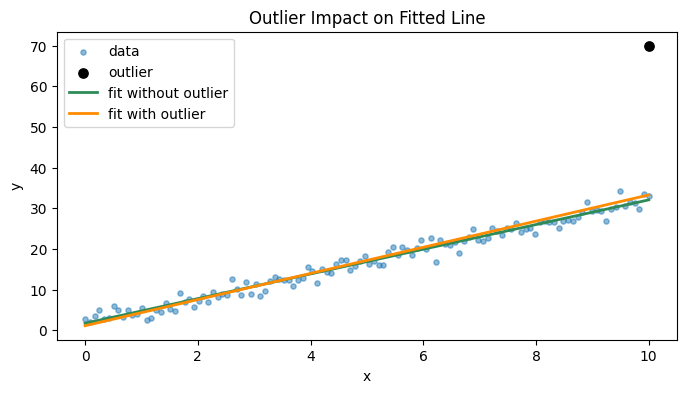

In [7]:
# Add an extreme outlier
X_out = np.append(X, [10.0])
y_out = np.append(y, [70.0])

# Fit on normal data
w_clean, b_clean, _ = train_linear_regression_gd(X, y, lr=0.01, epochs=3000)
pred_clean = w_clean * X + b_clean

# Fit on outlier data
w_out, b_out, _ = train_linear_regression_gd(X_out, y_out, lr=0.01, epochs=3000)
pred_out = w_out * X + b_out

print("Without outlier:")
print(f"  MSE={mse(y, pred_clean):.3f}, MAE={mae(y, pred_clean):.3f}")
print("With outlier-trained line evaluated on original points:")
print(f"  MSE={mse(y, pred_out):.3f}, MAE={mae(y, pred_out):.3f}")

plt.scatter(X, y, s=14, alpha=0.5, label='data')
plt.scatter([10], [70], color='black', s=45, label='outlier')
plt.plot(X, pred_clean, color='seagreen', linewidth=2, label='fit without outlier')
plt.plot(X, pred_out, color='darkorange', linewidth=2, label='fit with outlier')
plt.title('Outlier Impact on Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Practice

1. Re-run with noisier data (`noise std = 3.0`) and compare learned `w`/`b`.
2. Increase epochs and inspect whether gains saturate.
3. Add feature scaling (`x -> (x - mean)/std`) and compare convergence speed.